# Day 4 · Notebook 3 — Computer vision in practice
### ML Bootcamp · Day 4 of 5

No training today — we use **ready-made, state-of-the-art models** to do the four big vision tasks:

| Task | Question it answers |
|---|---|
| **Classification** | What is in the picture? |
| **Detection** | What objects, and **where** (boxes)? |
| **Segmentation** | Which exact **pixels** belong to each object? |
| **Pose estimation** | Where are the body **joints**? |

In this notebook you will:
1. Use **OpenCV** to load, edit and draw on images *(Part 1)*
2. **Detect** objects with **YOLO11** *(Part 2)*
3. Try **classification, segmentation and pose** *(Part 3)*
4. Run it all on **your own photo** *(Part 4)*

> Works on CPU; a GPU makes it faster. Run cells in order with **Shift + Enter**. ✍️ = exercise.

In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 6.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import urllib.request, collections, time
import cv2
from ultralytics import YOLO

base = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/"
for f in ["bus.jpg", "zidane.jpg"]:
    urllib.request.urlretrieve(base + f, f)

def show(img_rgb, title="", size=(8, 8)):
    plt.figure(figsize=size); plt.imshow(img_rgb); plt.title(title, fontsize=14); plt.axis("off"); plt.show()
print("Ready!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ready!


---
## Part 1 · OpenCV basics
**OpenCV** is the classic image toolbox: read/resize/rotate images, filters, edges, drawing. Deep learning does the recognising; OpenCV does the plumbing.

⚠️ OpenCV stores colours as **B, G, R** (not R, G, B). Always convert before showing with matplotlib.

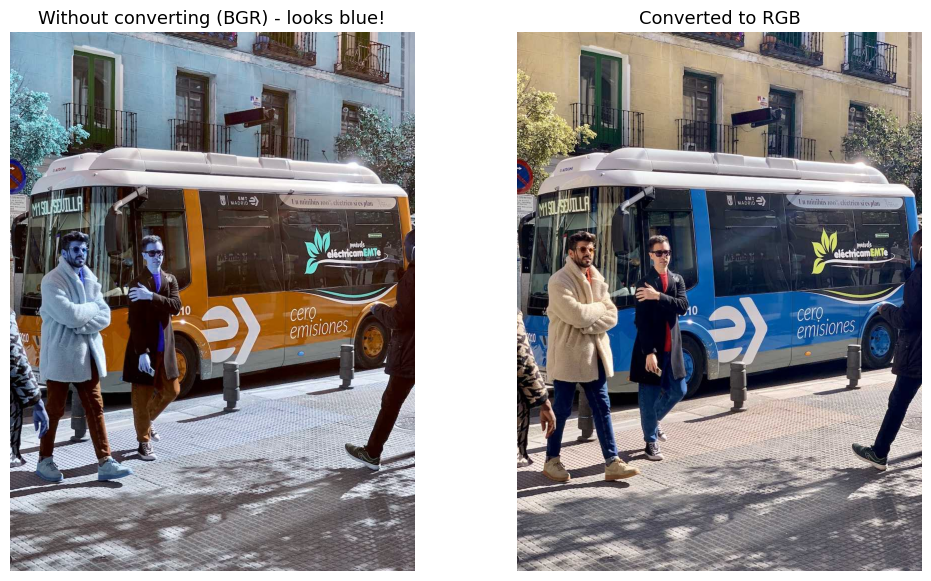

Size (height, width, channels): (1080, 810, 3)


In [3]:
bgr = cv2.imread("bus.jpg")
fig, axes = plt.subplots(1, 2, figsize=(12, 7))
axes[0].imshow(bgr); axes[0].set_title("Without converting (BGR) - looks blue!", fontsize=13)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
axes[1].imshow(rgb); axes[1].set_title("Converted to RGB", fontsize=13)
for a in axes: a.axis("off")
plt.show()
print("Size (height, width, channels):", rgb.shape)

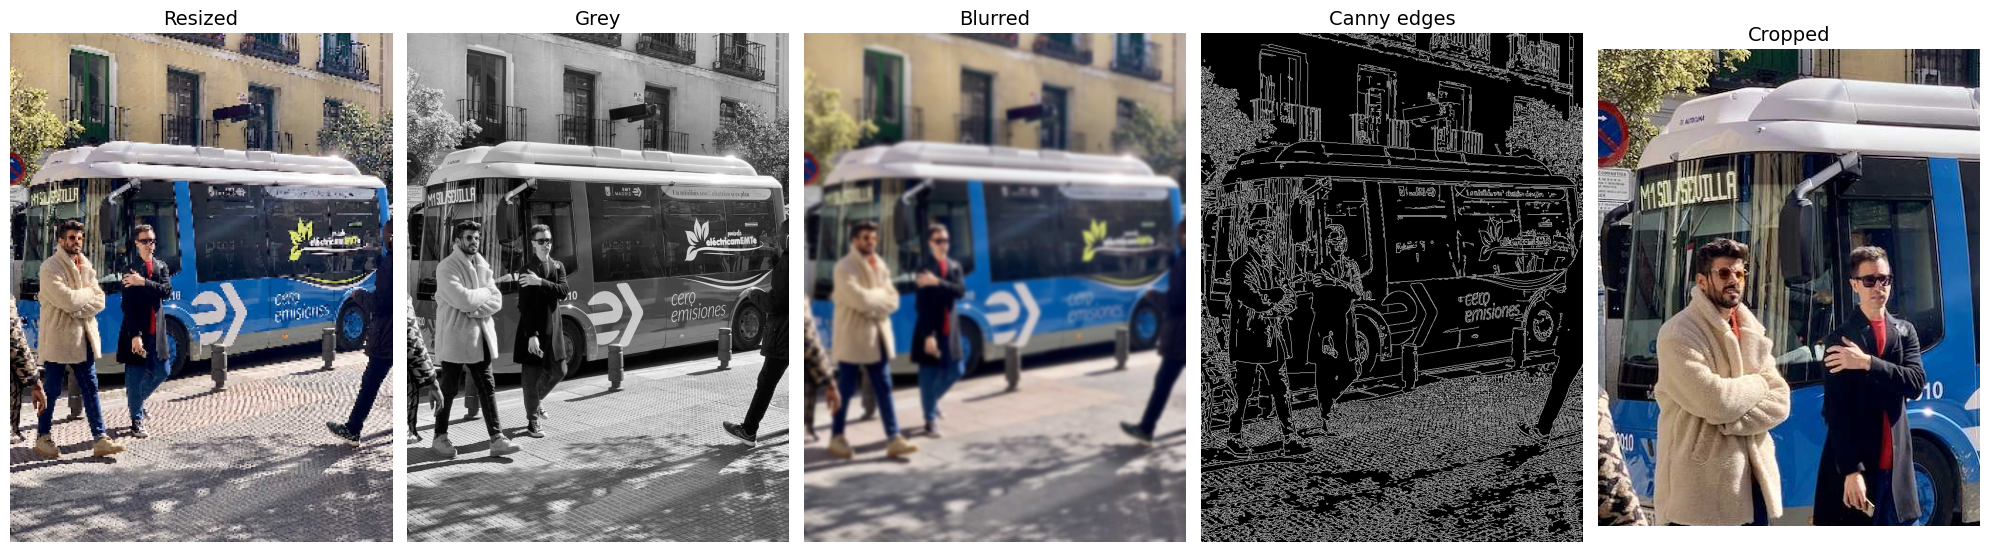

In [4]:
small = cv2.resize(rgb, (270, 360))                     # (width, height)
gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
blur = cv2.GaussianBlur(rgb, (21, 21), 0)
edges = cv2.Canny(gray, 100, 200)                        # the classic edge detector
crop = rgb[200:700, 0:400]                               # rows 200-700, columns 0-400 (just NumPy slicing!)

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
for a, im, t in zip(axes, [small, gray, blur, edges, crop], ["Resized", "Grey", "Blurred", "Canny edges", "Cropped"]):
    a.imshow(im, cmap="gray" if im.ndim == 2 else None); a.set_title(t, fontsize=14); a.axis("off")
plt.tight_layout(); plt.show()

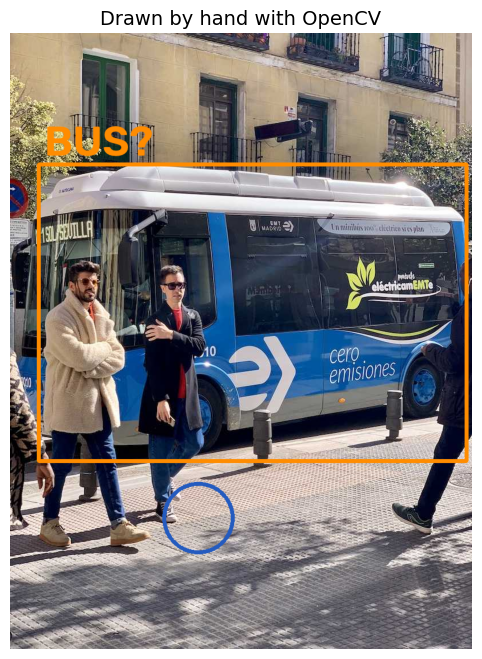

In [5]:
# Drawing: rectangles, circles and text (this is how detection boxes are drawn)
canvas = rgb.copy()
cv2.rectangle(canvas, (50, 230), (800, 750), (255, 140, 0), 6)            # (x1, y1), (x2, y2), colour, thickness
cv2.circle(canvas, (330, 850), 60, (36, 91, 191), 6)
cv2.putText(canvas, "BUS?", (60, 215), cv2.FONT_HERSHEY_SIMPLEX, 2.5, (255, 140, 0), 6)
show(canvas, "Drawn by hand with OpenCV")

✍️ **Exercise 1:** rotate the image with `cv2.rotate(rgb, cv2.ROTATE_90_CLOCKWISE)` and flip it with `cv2.flip(rgb, 1)`. (Flipping and rotating are also used to create extra training images — "data augmentation".)

---
## Part 2 · Object detection with YOLO
**YOLO = You Only Look Once**: one pass through the network finds every object. We use **YOLO11 nano** (2.6 million weights) trained on the **COCO** dataset: **80 everyday object types** — person, car, bus, dog, phone, bottle…

Three lines of code:


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 8.0ms
Speed: 83.4ms preprocess, 8.0ms inference, 36.4ms postprocess per image at shape (1, 3, 640, 480)


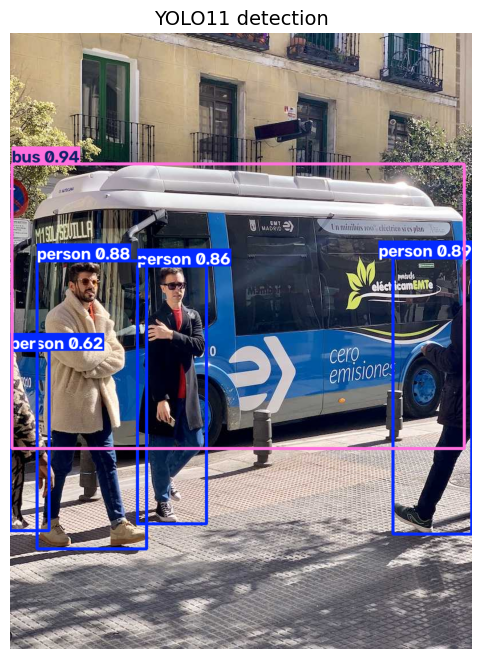

In [6]:
model = YOLO("yolo11n.pt")          # downloads ~5 MB the first time
results = model("bus.jpg")          # run detection
show(results[0].plot()[:, :, ::-1], "YOLO11 detection")   # .plot() draws the boxes (BGR -> RGB)

In [7]:
r = results[0]
print("Found", len(r.boxes), "objects:")
for box, cls, conf in zip(r.boxes.xyxy, r.boxes.cls, r.boxes.conf):
    x1, y1, x2, y2 = box.int().tolist()
    print(f"  {r.names[int(cls)]:8s} confidence {conf:.2f}   box ({x1},{y1}) -> ({x2},{y2})")

Found 5 objects:
  bus      confidence 0.94   box (3,229) -> (796,728)
  person   confidence 0.89   box (671,394) -> (809,878)
  person   confidence 0.88   box (47,399) -> (239,904)
  person   confidence 0.86   box (223,408) -> (344,860)
  person   confidence 0.62   box (0,556) -> (68,872)


In [8]:
# How fast is it?
t = time.time()
for _ in range(5):
    model("bus.jpg", verbose=False)
ms = (time.time() - t) / 5 * 1000
print(f"{ms:.0f} ms per image  ->  about {1000/ms:.0f} images per second")

17 ms per image  ->  about 58 images per second


Counter({'person': 2, 'tie': 1})


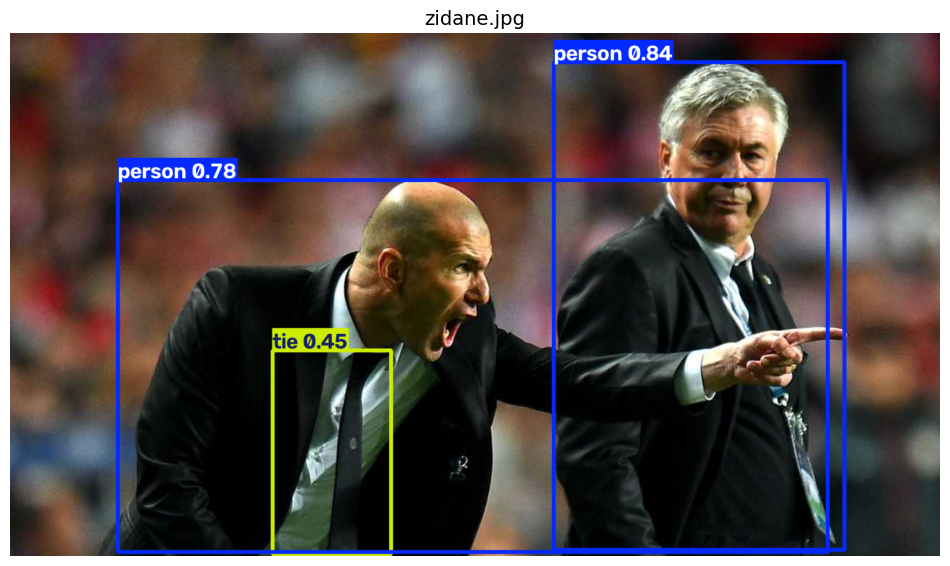

In [9]:
# Counting objects, and filtering by confidence
r = model("zidane.jpg", conf=0.25, verbose=False)[0]
print(collections.Counter(r.names[int(c)] for c in r.boxes.cls))
show(r.plot()[:, :, ::-1], "zidane.jpg", size=(12, 7))

🧠 Try `conf=0.6` in the cell above — which detection disappears? The **confidence threshold** is a trade-off, like the precision/recall trade-off from Day 2.

✍️ **Exercise 2:** YOLO can detect only some classes: `model("bus.jpg", classes=[0])` keeps only class 0 (person). Count the people. Print `model.names` to see all 80 classes.

---
## Part 3 · Classification, segmentation and pose
Same library — just change the model file.

In [10]:
# Classification: one label for the whole picture (1,000 ImageNet classes)
cls_model = YOLO("yolo11n-cls.pt")
r = cls_model("bus.jpg", verbose=False)[0]
for i in r.probs.top5:
    print(f"{r.names[i]:15s} {r.probs.data[i]:.3f}")

minibus         0.571
police_van      0.337
trolleybus      0.042
recreational_vehicle 0.014
streetcar       0.006


Objects: Counter({'person': 4, 'bus': 1, 'stop sign': 1})
Masks shape: (6, 640, 480) = (objects, height, width)


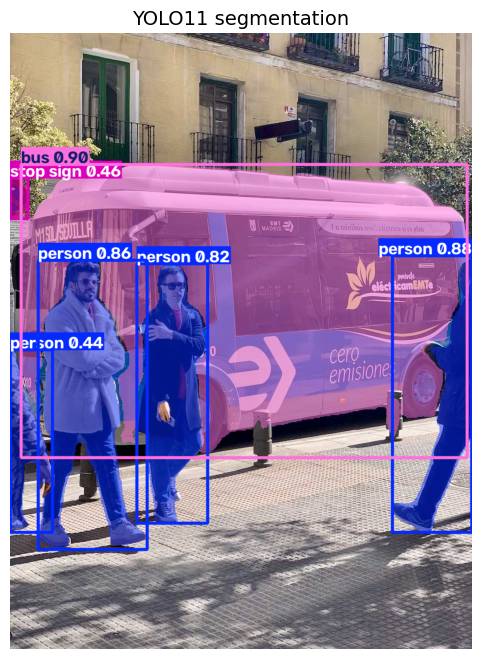

In [11]:
# Segmentation: the exact pixels of each object
seg_model = YOLO("yolo11n-seg.pt")
r = seg_model("bus.jpg", verbose=False)[0]
print("Objects:", collections.Counter(r.names[int(c)] for c in r.boxes.cls))
print("Masks shape:", tuple(r.masks.data.shape), "= (objects, height, width)")
show(r.plot()[:, :, ::-1], "YOLO11 segmentation")

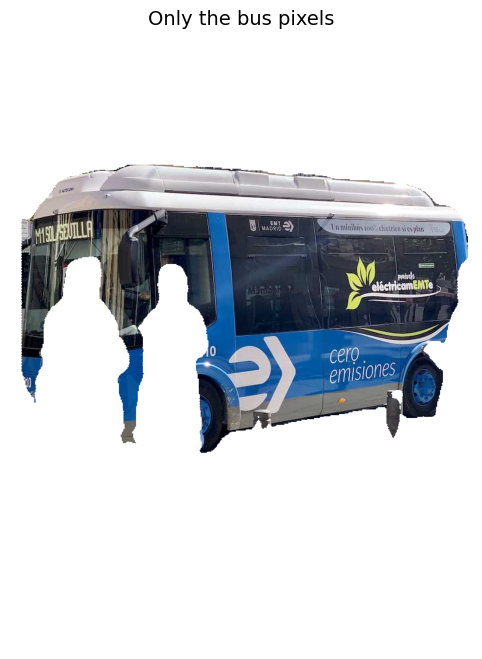

In [12]:
# Use a mask: cut the bus out of the photo
names = [r.names[int(c)] for c in r.boxes.cls]
bus_mask = r.masks.data[names.index("bus")].cpu().numpy()
bus_mask = cv2.resize(bus_mask, (rgb.shape[1], rgb.shape[0])) > 0.5
cut = np.where(bus_mask[..., None], rgb, 255)
show(cut, "Only the bus pixels")

People found: 2
Key points per person: 17


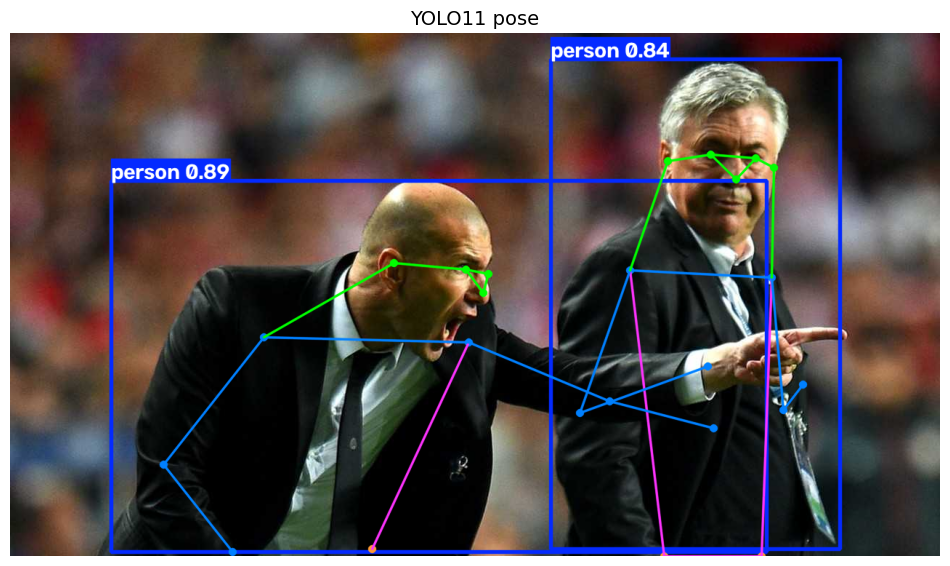

In [13]:
# Pose estimation: 17 body key points per person
pose_model = YOLO("yolo11n-pose.pt")
r = pose_model("zidane.jpg", verbose=False)[0]
print("People found:", len(r.keypoints))
print("Key points per person:", r.keypoints.xy.shape[1])
show(r.plot()[:, :, ::-1], "YOLO11 pose", size=(12, 7))

In [14]:
# The 17 COCO key points, in order
kp_names = ["nose", "left eye", "right eye", "left ear", "right ear", "left shoulder", "right shoulder",
            "left elbow", "right elbow", "left wrist", "right wrist", "left hip", "right hip",
            "left knee", "right knee", "left ankle", "right ankle"]
person = r.keypoints.xy[0].cpu().numpy()
for name, (x, y) in zip(kp_names, person):
    print(f"{name:15s} x={x:6.0f}  y={y:6.0f}" + ("   (not visible)" if x == 0 and y == 0 else ""))

nose            x=   652  y=   358
left eye        x=   659  y=   332
right eye       x=   627  y=   327
left ear        x=   618  y=   333
right ear       x=   529  y=   318
left shoulder   x=   631  y=   427
right shoulder  x=   350  y=   420
left elbow      x=   825  y=   508
right elbow     x=   211  y=   594
left wrist      x=   968  y=   544
right wrist     x=   307  y=   714
left hip        x=   499  y=   711
right hip       x=   319  y=   718
left knee       x=   509  y=   598
right knee      x=   265  y=   612
left ankle      x=   513  y=   712
right ankle     x=   297  y=   720


🧠 **Ideas:** from the key points you can compute angles — is the elbow bent? Are the arms raised? That's how fitness apps count push-ups and how fall-detection systems for the elderly work.

---
## Part 4 · Try it on your own photo
Run the cell, click **Choose Files** and upload any photo (a selfie, your room, the street, the classroom).

Not in Colab (or nothing uploaded) - using bus.jpg instead


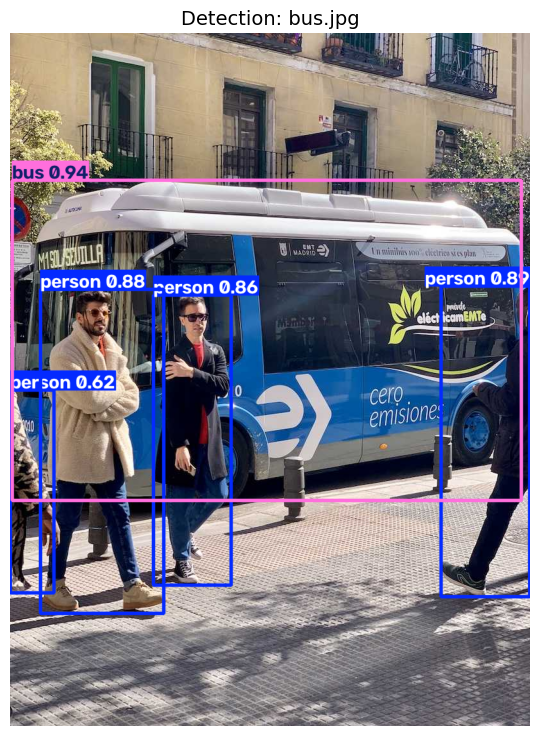

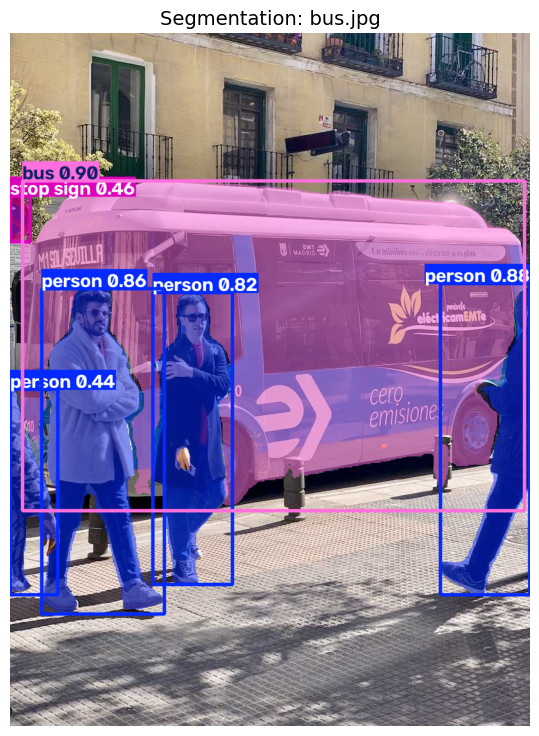

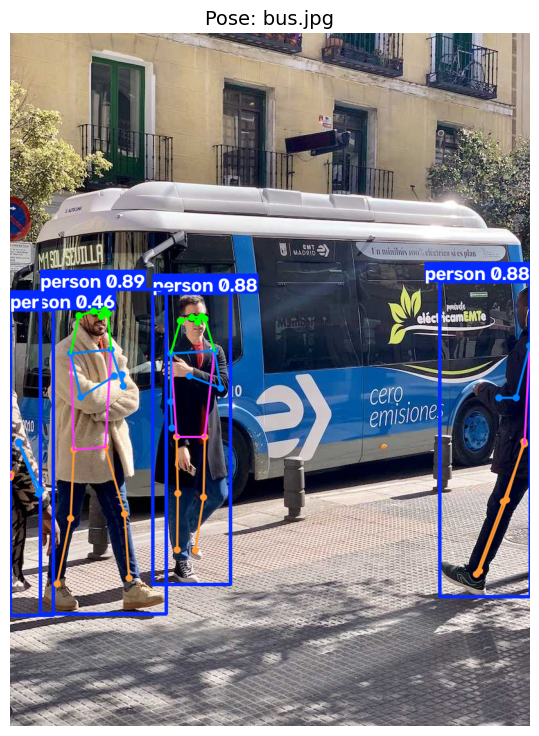

In [15]:
# Upload your own image (works in Colab). Outside Colab, set my_file to any image path.
my_file = "bus.jpg"
try:
    from google.colab import files
    uploaded = files.upload()
    my_file = list(uploaded.keys())[0]
except Exception as e:
    print("Not in Colab (or nothing uploaded) - using bus.jpg instead")

for m, title in [(model, "Detection"), (seg_model, "Segmentation"), (pose_model, "Pose")]:
    res = m(my_file, verbose=False)[0]
    show(res.plot()[:, :, ::-1], f"{title}: {my_file}", size=(9, 9))

🧠 Did it miss something, or call something the wrong name? Remember: it only knows the **80 COCO classes** — anything else (a cassava leaf, a keke napep, a jollof pot) it must guess as the closest thing it knows. To teach it new objects, you'd fine-tune it on your own labelled photos — transfer learning from Notebook 2.

### 🎥 Bonus: video and webcam
- **Video file:** `model("my_video.mp4", save=True)` saves an annotated video in `runs/detect/`.
- **Webcam on your laptop** (not Colab): `model(source=0, show=True)` opens a live window.
- **Raspberry Pi camera:** the same code runs on a Pi — that's Day 5!

---
## ✅ Summary
- **OpenCV**: load (BGR!), resize, blur, edges, crop, draw.
- **YOLO11** does detection, segmentation, pose and classification in ~3 lines each.
- Pre-trained models know only what they were trained on — fine-tune them for your own objects.

---
## Solutions

In [ ]:
# Exercise 1
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv2.rotate(rgb, cv2.ROTATE_90_CLOCKWISE)); axes[0].set_title("Rotated")
axes[1].imshow(cv2.flip(rgb, 1)); axes[1].set_title("Flipped left-right")
for a in axes: a.axis("off")
plt.show()

In [ ]:
# Exercise 2
r = model("bus.jpg", classes=[0], verbose=False)[0]
print("People:", len(r.boxes))
print(model.names)